# Tech Challenge - Fase 1: Modelagem Preditiva (Regressão)
**Objetivo:** Treinar um modelo de Machine Learning capaz de prever a nota exata de NPS (0 a 10) que um cliente dará, utilizando apenas os dados operacionais da sua jornada de compra.

---
### Por que Regressão e não Classificação? (Justificativa para a Banca)
Conforme analisado, a classe "Neutro" (notas 7 e 8) sofre com sobreposição de fronteiras na classificação tradicional. Ao utilizarmos um modelo de **Regressão**, prevemos o comportamento contínuo do cliente. Em seguida, aplicamos uma regra de negócio sobre a previsão para categorizá-lo (Classificação via Regressão), aumentando a precisão nas zonas de transição.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

## 1. Carregamento dos Dados e Divisão (Treino / Teste)
Garantimos que o modelo seja treinado com uma parte dos dados (80%) e testado em dados inéditos (20%), evitando o *overfitting* (vício do modelo).

In [3]:
# 1. Carregando a base limpa do Notebook 01
df = pd.read_csv('dados_preparados_regressao.csv')

# 2. Separando as variáveis preditoras (X) e a variável alvo (y = nps_score)
X = df.drop(columns=['nps_score'])
y = df['nps_score']

# 3. Divisão de Treino e Teste (80/20) - Ponto 4 do Feedback
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Base de Treino: {X_train.shape[0]} clientes.")
print(f"Base de Teste: {X_test.shape[0]} clientes (Usados para prova real).")

Base de Treino: 2000 clientes.
Base de Teste: 500 clientes (Usados para prova real).


## 2. Treinamento do Modelo Preditivo
Utilizaremos o `RandomForestRegressor`. Este algoritmo cria múltiplas "árvores de decisão" para entender como as variáveis operacionais (como atraso e frete) se combinam para formar a nota do cliente.

In [5]:
# Inicializando o modelo de regressão
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)

# Treinando o modelo
modelo_rf.fit(X_train, y_train)

# Fazendo as previsões na base de teste
y_pred = modelo_rf.predict(X_test)

print("Modelo treinado e previsões realizadas com sucesso!")

Modelo treinado e previsões realizadas com sucesso!


## 3. Avaliação de Performance (Métricas de Regressão)
Como estamos prevendo uma nota de 0 a 10, utilizamos métricas de erro contínuo:
* **MAE (Erro Médio Absoluto):** Indica quantos pontos, em média, o modelo erra a nota do cliente.
* **R²:** Indica a porcentagem da nota que é explicada pela nossa operação.

In [7]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- PERFORMANCE DO MODELO ---")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} pontos")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.2f} pontos")
print(f"R² (Poder de Explicação): {r2:.2f}")

--- PERFORMANCE DO MODELO ---
MAE (Erro Médio Absoluto): 1.25 pontos
RMSE (Raiz do Erro Quadrático): 1.55 pontos
R² (Poder de Explicação): 0.62


## 4. Classificação via Regressão
Para atender à necessidade de negócio (saber quem é Detrator, Neutro ou Promotor) sem perder a precisão da matemática contínua, criamos uma regra sobre a nota prevista pelo modelo. 
Se o modelo prevê nota `8.6`, classificamos o cliente como Promotor. Isso resolve o problema de sobreposição da classe "Neutra".

In [8]:
# Criando um DataFrame para comparar o Real vs Previsto
resultados = pd.DataFrame({
    'Nota_Real': y_test.values,
    'Nota_Prevista': y_pred
})

# Função para classificar com base na nota
def classificar_nps(nota):
    if nota <= 6.5: return 'Detrator'
    elif nota < 8.5: return 'Neutro'
    else: return 'Promotor'

# Aplicando a regra
resultados['Classe_Real'] = resultados['Nota_Real'].apply(classificar_nps)
resultados['Classe_Prevista'] = resultados['Nota_Prevista'].apply(classificar_nps)

display(resultados.head(10))

,Nota_Real,Nota_Prevista,Classe_Real,Classe_Prevista
0,6.8,4.896041,Neutro,Detrator
1,6.0,5.125274,Detrator,Detrator
2,8.3,9.511016,Neutro,Promotor
3,5.3,5.082188,Detrator,Detrator
4,6.8,5.399964,Neutro,Detrator
5,0.0,2.992652,Detrator,Detrator
6,1.4,0.269038,Detrator,Detrator
7,7.4,5.428004,Neutro,Detrator
8,5.2,5.237000,Detrator,Detrator
9,0.8,2.967439,Detrator,Detrator


## 5. Storytelling: O que afeta o NPS? (Feature Importance)
Para gerar insights acionáveis para a diretoria, precisamos saber: **Para onde o modelo olha na hora de dar a nota?** O gráfico abaixo revela as alavancas operacionais mais críticas.

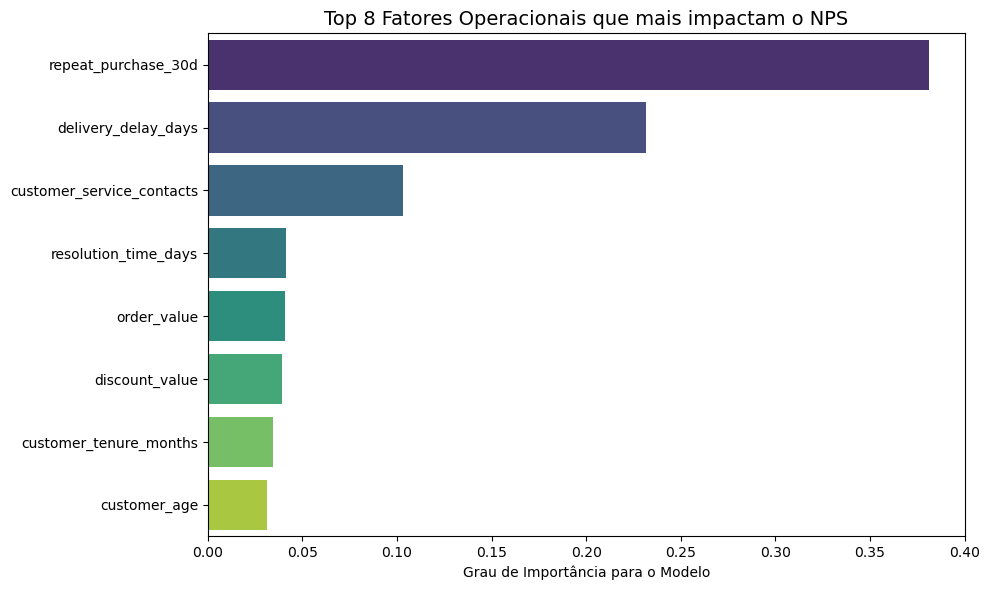

In [9]:
# Extraindo a importância de cada coluna
importancias = modelo_rf.feature_importances_
colunas = X.columns

# Criando um DataFrame para o gráfico
df_imp = pd.DataFrame({'Variavel': colunas, 'Importancia': importancias})
df_imp = df_imp.sort_values(by='Importancia', ascending=False).head(8) # Top 8 fatores

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variavel', data=df_imp, palette='viridis')
plt.title('Top 8 Fatores Operacionais que mais impactam o NPS', fontsize=14)
plt.xlabel('Grau de Importância para o Modelo')
plt.ylabel('')
plt.tight_layout()
plt.show()